## DLA CODE OF CONDUCT V2.0

This Code of Conduct defines the principles governing ethical, transparent, and responsible use of Large Language Models (LLMs), online resources, and peer collaboration in the Deep Learning Applications laboratories. This version of the Code of Conduct was refined via a brainstorming session with **ChatGPT Version 5.2** and subsequently adapted to reflect the specific requirements and values of the DLA laboratories. In that spirit, this Code itself models the transparency it expects from you.

***Our goal is not to restrict innovation, but to ensure integrity, accountability, and genuine learning.***

### 1. Transparency in the Use of LLMs and AI Tools

The use of LLMs and AI-assisted tools is permitted â€” *but it must be transparent*.

* **Explicit Disclosure:** Clearly state if and how LLMs (e.g., ChatGPT, Copilot, Claude, etc.) were used. This includes code generation, debugging, data analysis, experiment design, report writing, or conceptual clarification.
* **Description of Contribution:** Briefly describe what the tool contributed and how you modified, verified, or extended its output.
* **Acknowledgment of Limitations:** Recognize that LLM outputs may contain errors, biases, or non-optimal solutions. You are responsible for verifying correctness, appropriateness, and academic integrity.

***Using AI does not reduce your responsibility for the final result.***

### 2. Proper Attribution and Documentation

Deep learning builds on existing work â€” responsibly.

* **Attribution:** Properly cite all external resources, including: Code snippets, Tutorials, Documentation, Datasets, Pretrained models, Research papers, and AI-generated content.
* **Reproducibility:** Clearly document tools, libraries, model versions, hyperparameters, and experimental setups so that your work can be reproduced.
* **Clarity of Modifications:** If you adapt external code, explicitly indicate what you changed and why.

***Transparency is a sign of scientific maturity â€” not weakness.***

### 3. Collaboration and Individual Responsibility

Discussion is encouraged. Copying is not.

* **Collaborative Learning:** You are encouraged to discuss concepts, debugging strategies, and approaches with classmates.
* **Individual Submission:** Your submitted solution must reflect your own understanding and implementation.
* **No Direct Sharing of Solutions:** Do not share complete solutions, trained models, or reports. Do not submit another person's work â€” or AI-generated work â€” as your own without meaningful engagement and proper disclosure.

***If you cannot explain your submission, it is not your submission.***

### 4. Accountability and Academic Integrity

You are responsible for everything you submit. Failure to comply with these guidelines may result in review by the course examination commission and can lead to disciplinary measures in accordance with university regulations.

***Integrity is part of your training as a machine learning practitioner.***

### 5. The Spirit of This Code of Conduct

This course prepares you to work in a field where:

* Reproducibility matters
* Ethical considerations matter
* Transparency matters
* Responsible AI use matters

***The purpose of this Code of Conduct is not surveillance â€” it is professional formation.***

### TL;DR

Use AI; Donâ€™t let AI use you; Be transparent; Cite everything; Do your own thinking.

***If you canâ€™t explain it, you probably shouldnâ€™t submit it.***

---
---

## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [21]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Import standard e alias principali.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms.v2 as T     # Usiamo le transforms v2, piu' efficienti.
from torchvision.datasets import GTSRB

# Implementazione dello studente.

# Device globale usato nelle celle successive.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Implementazione dello studente.
transform = T.Compose([T.ToTensor()])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

c:\Users\franc\Desktop\Deep_Learning_Laboratories\dla_env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [22]:
ds_train[0][0].shape

torch.Size([3, 30, 29])

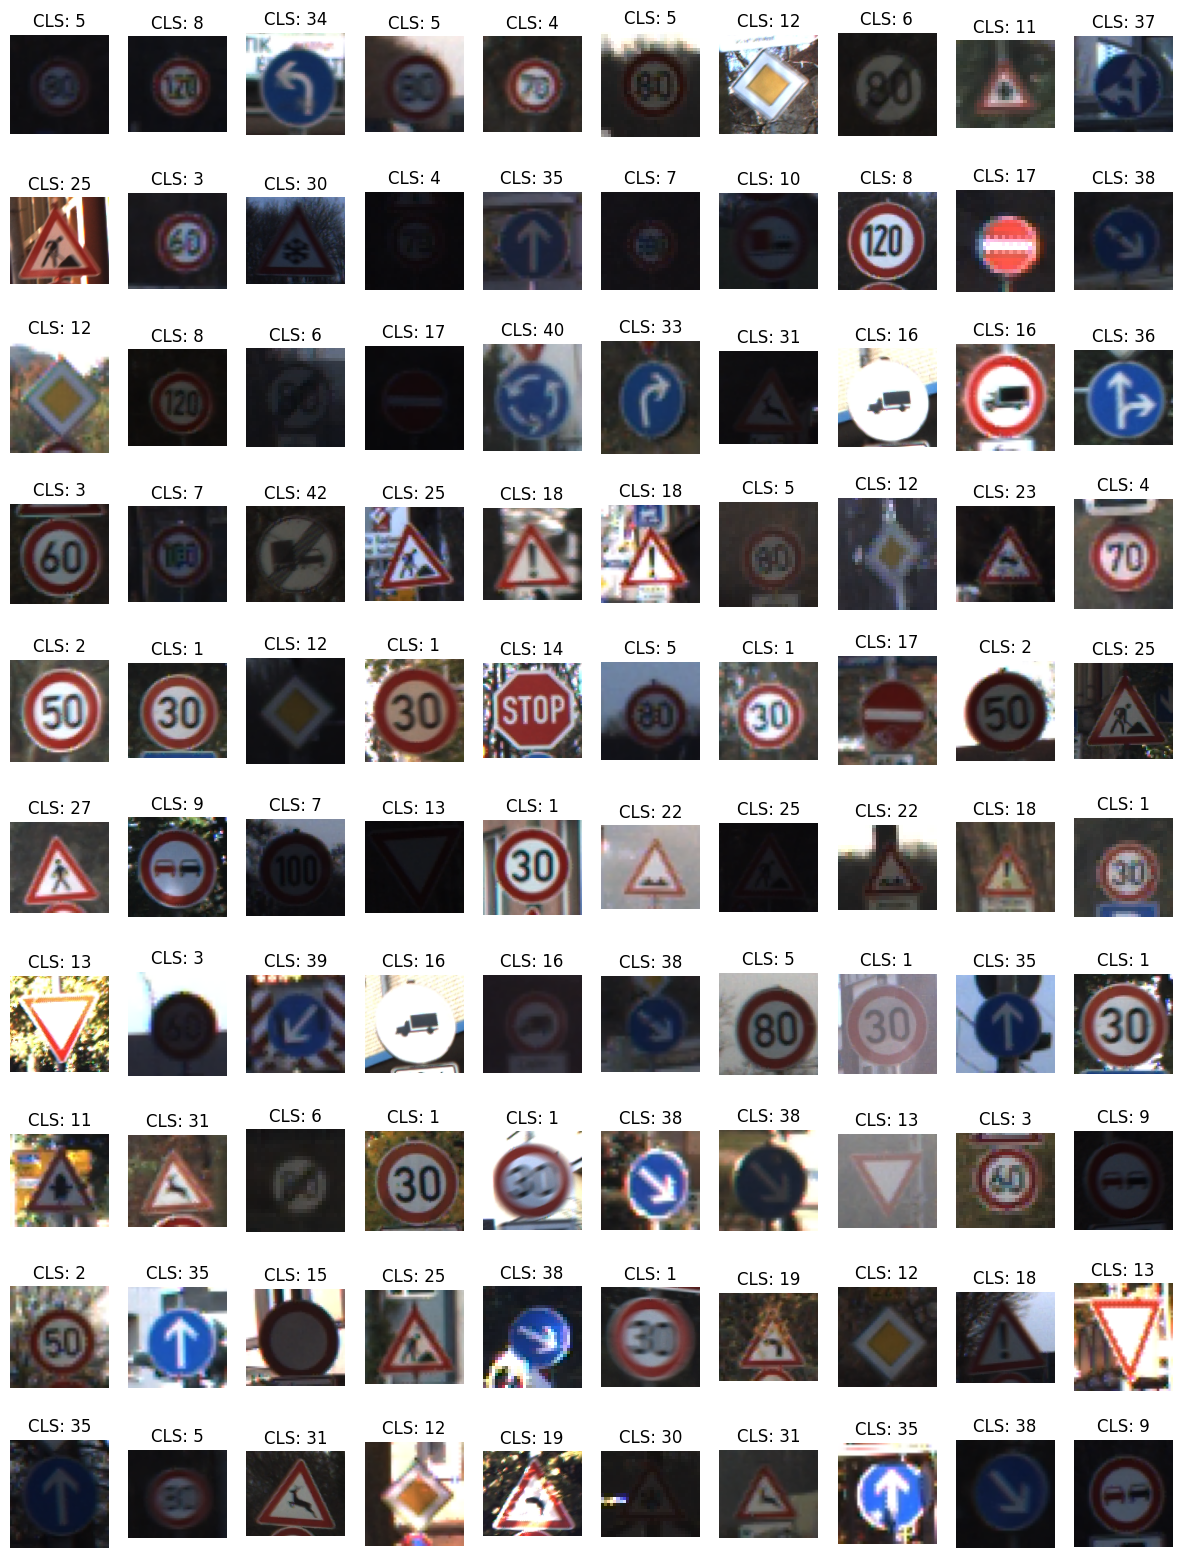

In [23]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

plt.figure(figsize=(15,20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    plt.title(f'CLS: {cls}')
    plt.axis('off')

In [24]:
# Raccolta delle statistiche dei metadati in un DataFrame pandas.
import pandas as pd
df_stats = pd.DataFrame([(cls, im.shape[1], im.shape[2]) for (im, cls) in ds_train], columns=['CLS', 'HEIGHT', 'WIDTH'])
df_stats['AR'] = df_stats['WIDTH'] / df_stats['HEIGHT']

In [25]:
df_stats.describe()

,CLS,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000,26640.000000
mean,15.887387,50.365128,50.933784,1.008718
std,12.044099,23.161523,24.373418,0.072100
min,0.000000,25.000000,25.000000,0.368132
25%,5.000000,35.000000,35.000000,0.972222
50%,12.000000,43.000000,43.000000,1.000000
75%,25.000000,58.000000,58.000000,1.044444
max,42.000000,225.000000,243.000000,1.417808


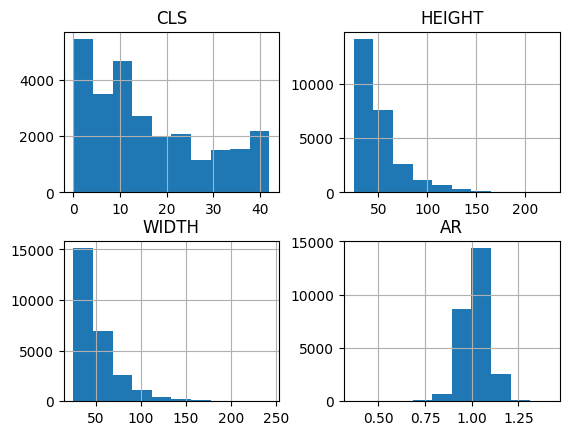

In [26]:
_ = df_stats.hist()

In [27]:
# The "final" transform.
# Usiamo le statistiche di normalizzazione standard della ResNet in torchvision.
transform = T.Compose([T.Resize(70), T.RandomCrop((64, 64)), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
ds_train = GTSRB('_data/', split='train', transform=transform, download=True)
ds_test  = GTSRB('_data/', split='test', transform=transform, download=True)

c:\Users\franc\Desktop\Deep_Learning_Laboratories\dla_env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555357..1.7162529].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..-0.9329847].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..0.11276696].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..-0.9852723].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4671633..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..0.51363856].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.004795..

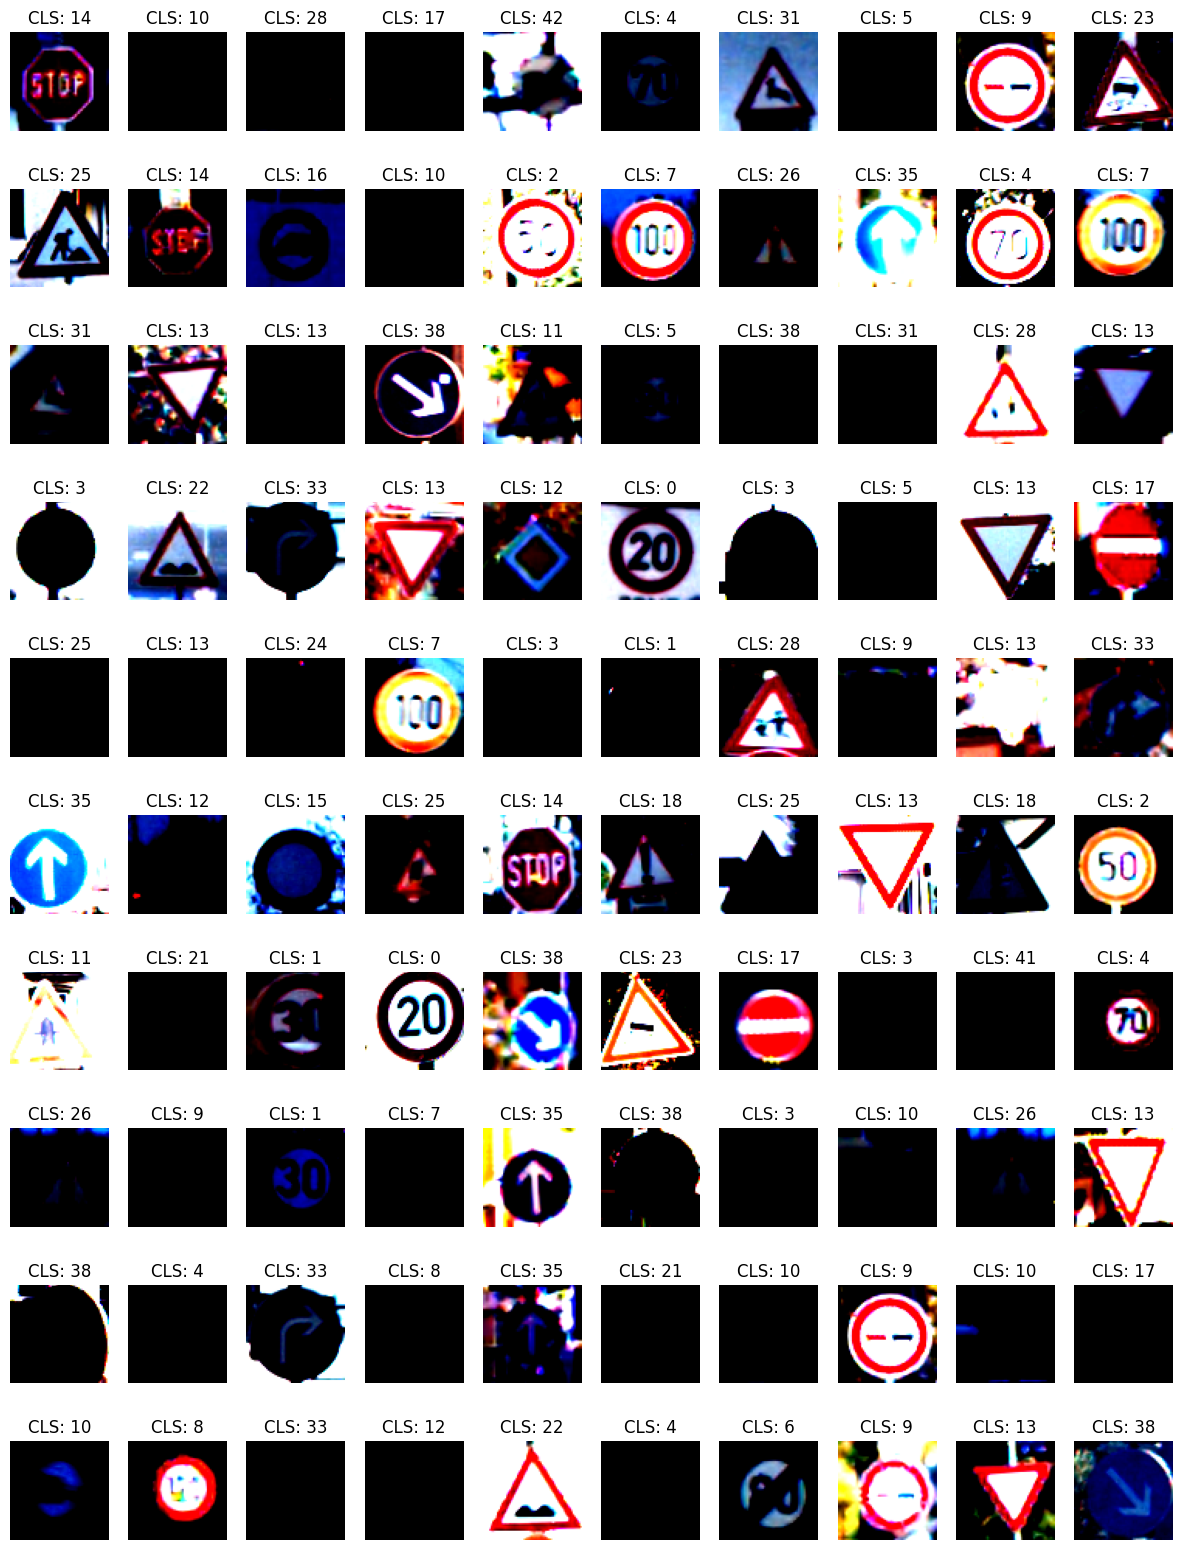

In [28]:
num_samples = 100
image_samples = [ds_train[idx] for idx in np.random.choice(range(len(ds_train)), num_samples)]

plt.figure(figsize=(15,20))
for (idx, (im, cls)) in enumerate(image_samples):
    plt.subplot(10, 10, idx+1)
    plt.imshow(im.permute([1, 2, 0]))
    plt.title(f'CLS: {cls}')
    plt.axis('off')

### Analysis

Deep Learning is very much an *experimental* discipline. Experiments are *nothing* without analysis and interpretation. Be sure to **always** stop and analyze the results of preliminary explorations. Note anything significant and -- importantly -- anything that is going to be relevant for what comes next.

So... In this Markdown cell you should collect and report (using, for the love of God, the *rich markup capabilities of Markdown*) any relevant findings you have made before proceeding.

**Important Warning**: This is the **one and only** time I will remind you of the need to provide *analysis* and interpretation of your experimental methodology and results. The responsibility is *yours* to include it elsewhere.


---
### Exercise 1.2: A Stable and Reproducible Baseline

In questo esercizio si costruisce una baseline riproducibile usando feature estratte da una CNN preaddestrata e un classificatore semplice. Lo scopo e' ottenere un riferimento stabile prima del fine-tuning end-to-end.

In [ ]:
from torchvision.models import list_models, get_model

In [ ]:
list_models()

In [ ]:
len(ds_test), len(ds_train)

In [ ]:
# Implementazione dello studente.
from torch.utils.data import DataLoader
import torch.nn as nn

# DataLoader del training set.
batch_size = 1024
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, )
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=True)

# Caricamento del modello ResNet.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Identity()  # Rimuoviamo il classificatore finale per estrarre feature.
model = model.to(device)

In [ ]:
from tqdm import tqdm as text_tqdm

train_feats = []
train_classes = []
model.eval()
for (ims, cls) in dl_train:
    ims = ims.to(device)
    with torch.no_grad():
        train_feats.append(model(ims))
    train_classes.append(cls)
train_feats = torch.vstack(train_feats).cpu()
train_classes = torch.concat(train_classes)

In [ ]:
train_feats.shape

In [ ]:
test_feats = []
test_classes = []
model.eval()
for (ims, cls) in dl_test:
    ims = ims.to(device)
    with torch.no_grad():
        test_feats.append(model(ims))
    test_classes.append(cls)
test_feats = torch.vstack(test_feats).cpu()
test_classes = torch.concat(test_classes)

In [ ]:
# Baseline riproducibile, coerente con il notebook del professore.
from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(train_feats, train_classes)
svc

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_classes, svc.predict(test_feats)))


---
### Exercise 1.3: A Fine-tuning Baseline

In questo esercizio si adatta una CNN preaddestrata al dataset GTSRB aggiornando il classificatore finale e ottimizzando l'intera rete. Lo scopo e' confrontare il fine-tuning con la baseline basata su feature congelate.

In [ ]:
# Codice di training minimale usato come riferimento didattico.
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import torch.nn.functional as F

# Funzione per addestrare il modello per una singola epoca sul DataLoader.
def train_epoch(model, dl, opt, epoch='Unknown', device='cpu'):
    model.train()
    losses = []
    for (xs, ys) in tqdm(dl, desc=f'Training epoch {epoch}', leave=True):
        xs = xs.to(device)
        ys = ys.to(device)
        opt.zero_grad()
        logits = model(xs)
        loss = F.cross_entropy(logits, ys)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return np.mean(losses)

# Funzione per valutare il modello su tutti i campioni del DataLoader.
def evaluate_model(model, dl, device='cpu'):
    model.eval()
    predictions = []
    gts = []
    for (xs, ys) in tqdm(dl, desc='Evaluating', leave=False):
        xs = xs.to(device)
        preds = torch.argmax(model(xs), dim=1)
        gts.append(ys)
        predictions.append(preds.detach().cpu().numpy())
        
    # Restituisce accuracy e classification report.
    return (accuracy_score(np.hstack(gts), np.hstack(predictions)),
            classification_report(np.hstack(gts), np.hstack(predictions), zero_division=0, digits=3))

# Funzione semplice per contare i parametri di un modello.
def count_parameters(model):
    return np.sum([p.numel() for p in model.parameters()])

In [ ]:
# Implementazione dello studente.

# Caricamento del modello ResNet.
model = get_model('resnet18', weights='DEFAULT')
model.fc = nn.Linear(512, 43)  # Sostituiamo il classificatore finale per predire le 43 classi GTSRB.
model = model.to(device)

# DataLoader del training set.
batch_size = 512
dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
dl_test = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=0)

In [ ]:
epochs = 30
lr = 0.0001
from tqdm import tqdm as text_tqdm

# Verifica esplicita dell'uso della GPU prima dell'addestramento.
print(f"Device selezionato: {device}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU rilevata: {torch.cuda.get_device_name(0)}")
    print(f"Memoria CUDA allocata prima del training: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")

model_device = next(model.parameters()).device
print(f"Device del modello: {model_device}")
if model_device.type != 'cuda':
    raise RuntimeError("Il modello non e' su CUDA: interrompo il training per evitare esecuzione su CPU.")

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

losses = []
for epoch in text_tqdm(range(epochs)):
    losses.append(train_epoch(model, dl_train, optimizer, epoch+1, device=device))

plt.plot(losses)
(accuracy, cls_report) = evaluate_model(model, dl_test, device=device)
print(cls_report)

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

In [ ]:
# L'Esercizio 2 e' consolidato nel notebook dedicato:
# DLA_LAB1/exercise_2_gtsrb_classification/05_pipeline_experiments.ipynb
# La logica riusabile vive nei moduli Python:
# DLA_LAB1/src

# Questo notebook del professore resta come traccia di riferimento.
# Per lanciare nuovi esperimenti usare il notebook centrale dell'Esercizio 2.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 

---
### Exercise 3.1 (Easy): Improving Fine-tuning Performance

In this exercise you are asked to iterate on the fine-tuning experiment performed in Exercise 1.3 in order to squeeze the best performance possible out of the model.

What can we do:
- Use a more powerful model?
- More aggressive data augmentation?
- Selective layer training?
- Something else?

**Why choose this exercise?** To hone your skills at incrementally improving fined-tuned model performance via a sequence of (carefully monitored) experiments.

In [ ]:
# Implementazione dello studente.


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will avoid the need to perform extensive fine-tuning of our model and will instead count on the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.


---
### Exercise 3.3: *Detecting* Traffic Signs (hardest)

In this exercise you will see if you can take your pretrained *classification* backbone and turn it into a *detector*. We will need another dataset for this -- one with *full image frames* instead of cropped sign images. Luckily, this dataset is available on [Hugging Face](https://huggingface.co/datasets/keremberke/german-traffic-sign-detection) (see below for how to access it).

For this exercise, you could:
1. Start from an available Faster-RCNN model from `torchvision` and *replace* the feature extraction backbone with your ResNet fine-tuned on GTSRB.
2. This *stitched-together* network should do an OK-ish job already of detecting at least *some* traffic signs. See how it performs on some of the images from the GTSRB Detection dataset. Implement a simple function to visualize detections superimposed over the original image. Compute some detection metrics (accuracy @ IoU=0.5, for example).
3. If you're feeling ambitious, you could also *fine-tune* the resulting model to improve detection performance.

**NOTE**: The pretrained Faster-RCNN models in `torchvision` are all based on ResNet-50, so this exercise will likely be much less painful if you use a ResNet-50 from the very start.

**Also Note**: To use the **GTSRB Detection Dataset** you should use the `datasets` package from Hugging Face (version 3.X):

     # If using uv.
     uv add datasets==3

or

     # If using Anaconda
     conda install -c conda-forge datasets==3

In [ ]:
from datasets import load_dataset

# Download del dataset detection completo da Hugging Face Hub.
# Prima dell'uso operativo conviene studiare l'organizzazione del dataset.
ds = load_dataset("keremberke/german-traffic-sign-detection", name="full")

# Implementazione dello studente.

---
---